# 17. A pivotal bootstrap

::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Example 15 built a bootstrap out of four functions you write. This page is about the other run type
the ported Numerics `Bootstrap` class has, reached with `run_type="pivotal"`. It replaces the
resampled fit with a pivot of that fit around the original one, standardized through the resample's
own covariance and reinflated through the original's, so a replicate fitted on an unusually flat
likelihood contributes an appropriately smaller step. It therefore needs a covariance with every
fit, which is why it fits through a fifth function, `fit_with_covariance`, instead of `fit`.

Like examples 13 and 15, it has no upstream counterpart.

## What you'll learn

- What the pivotal transform does to a replicate, in one line of algebra.
- The signature of `fit_with_covariance`, the one function this run type adds.
- Both interval blocks a pivotal run reports, and why it reports two.
- `pivotal_diagnostics`: six counts that say what happened to the replicates you asked for.
- Standardizing in link space, and which links change the answer.
- Where the cross-language guarantee stops on the callback path, and how to stay inside it.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import corehydropy as ch

## The transform

Write $\theta$ for a parameter vector and $\Sigma$ for its covariance. The parent fit is
$(\hat{\theta}, \hat{\Sigma})$, from the whole sample; a replicate gives $(\theta^*, \Sigma^*)$.
With $L$ for the lower Cholesky factor of each covariance, the pivotal draw is

$$
z = (L^*)^{-1}(\hat{\theta} - \theta^*), \qquad
\theta^{\text{piv}} = \hat{\theta} + \hat{L} z
$$

Two things follow from the sign. The difference is taken parent minus replicate, so a replicate that
landed BELOW the parent produces a draw ABOVE it. The ensemble is reflected through the parent
rather than centered on the replicates, which is the same idea as the basic bootstrap's
$2\hat{\theta} - \theta^*$, generalized to a correlated parameter vector. And the step is measured
in units of the replicate's own standard error and re-expressed in units of the parent's, so a
replicate whose fit was poorly determined contributes a shorter step than one whose fit was sharp.

## The record and the model

Forty years of $\log_{10}$ annual peak discharge, drawn from a Normal population through the seeded
core so the R twin has the identical record. Working in $\log_{10}$ keeps the model a plain
location-scale Normal, whose maximum likelihood estimate and covariance are both closed form. That
matters here for a reason beyond convenience, taken up at the end of the page: it makes the callback
pure arithmetic.

In [2]:
log_peaks = ch.Distribution("Normal", [4.60, 0.22]).random(40, seed=2027)

mean = np.mean(log_peaks)
print(f"n = {len(log_peaks)}, mean = {mean:.4f} ({10 ** mean:.0f} cfs), "
      f"sd = {np.std(log_peaks):.4f}")

n = 40, mean = 4.6550 (45183 cfs), sd = 0.2067


The three functions the run needs. `resample` is the ordinary iid one from example 15, drawing its
indices from the generator the replicate hands it.

In [3]:
def resample_iid(data, parameters, rng):
    return [data[k] for k in rng.integers(len(data), 0, len(data))]

`fit_with_covariance(data)` is the one signature this run type adds. It returns
`{"parameters": ..., "covariance": ...}`: the fitted vector, and its covariance as a matrix with one
row and one column per parameter. For the Normal MLE both are textbook,
$\operatorname{Var}(\hat\mu) = \sigma^2/n$ and $\operatorname{Var}(\hat\sigma) = \sigma^2/2n$, with
no covariance between them.

In [4]:
def normal_mle(data):
    n = len(data)
    acc = 0.0
    for x in data:
        acc += x
    mu = acc / n
    ss = 0.0
    for x in data:
        ss += (x - mu) * (x - mu)
    return mu, ss / n, n


def fit_with_cov(data):
    mu, s2, n = normal_mle(data)
    return {"parameters": [mu, s2 ** 0.5],
            "covariance": [[s2 / n, 0.0],
                           [0.0, s2 / (2 * n)]]}


def fit_only(data):
    mu, s2, n = normal_mle(data)
    return [mu, s2 ** 0.5]

`statistic(parameters)` turns a parameter vector into the numbers to be given intervals. Here it
returns the two parameters and the design quantity built from them, the 1% annual chance
$\log_{10}$ peak, $\mu + z_{0.99}\sigma$. The standard normal deviate is computed once, outside the
callback, so the callback itself does nothing but multiply and add.

In [5]:
z99 = ch.Distribution("Normal", [0, 1]).quantile(0.99)


def design_statistic(parameters):
    return [parameters[0], parameters[1], parameters[0] + z99 * parameters[1]]

## The regular run, for comparison

In [6]:
regular = ch.bootstrap_custom(
    data=log_peaks, resample=resample_iid, fit=fit_only,
    statistic=design_statistic, replicates=400, alpha=0.1, seed=2027,
)

names = ["mean", "sd", "1% AEP"]


def show_block(estimate, lower, upper):
    print(f"{'statistic':>10} {'estimate':>10} {'lower':>10} {'upper':>10} {'width':>10}")
    for name, e, lo, hi in zip(names, estimate, lower, upper):
        print(f"{name:>10} {e:>10.6f} {lo:>10.6f} {hi:>10.6f} {hi - lo:>10.6f}")


show_block(regular["estimate"], regular["lower"], regular["upper"])

 statistic   estimate      lower      upper      width
      mean   4.654973   4.602628   4.703261   0.100632
        sd   0.206669   0.154681   0.255830   0.101149
    1% AEP   5.135757   5.026432   5.234595   0.208163


## The pivotal run

The same data, the same seed, the same statistic. `fit` is replaced by `fit_with_covariance`, and
passing both is an error rather than a silent preference for one of them.

In [7]:
piv = ch.bootstrap_custom(
    data=log_peaks, resample=resample_iid, statistic=design_statistic,
    fit_with_covariance=fit_with_cov, run_type="pivotal",
    replicates=400, alpha=0.1, seed=2027,
)

print("pivotal ensemble:")
show_block(piv["estimate"], piv["lower"], piv["upper"])
print("\nraw covariance-aware fits:")
show_block(piv["raw_estimate"], piv["raw_lower"], piv["raw_upper"])

pivotal ensemble:
 statistic   estimate      lower      upper      width
      mean   4.654973   4.600234   4.703902   0.103668
        sd   0.206669   0.166954   0.276130   0.109175
    1% AEP   5.135757   5.051078   5.277661   0.226584

raw covariance-aware fits:
 statistic   estimate      lower      upper      width
      mean   4.654973   4.602628   4.703261   0.100632
        sd   0.206669   0.154681   0.255830   0.101149
    1% AEP   5.135757   5.026432   5.234595   0.208163


A pivotal run reports two interval blocks, and comparing them is the point of reporting both. The
raw block is the plain percentile interval of the covariance-aware fits, before the transform. It is
the answer the regular run gives, and here it is that answer to the last bit, because the two runs
resampled the same observations in the same order from the same seed.

In [8]:
assert np.array_equal(regular["lower"], piv["raw_lower"])
assert np.array_equal(regular["upper"], piv["raw_upper"])
print("raw block and regular run agree exactly.")

raw block and regular run agree exactly.


The pivotal block is different, and on this sample it is wider on the two quantities that matter.

In [9]:
raw_width = piv["raw_upper"] - piv["raw_lower"]
pivotal_width = piv["upper"] - piv["lower"]

print(f"{'statistic':>10} {'raw_width':>10} {'pivotal_width':>14} {'ratio':>8}")
for name, rw, pw in zip(names, raw_width, pivotal_width):
    print(f"{name:>10} {rw:>10.4f} {pw:>14.4f} {pw / rw:>8.3f}")

 statistic  raw_width  pivotal_width    ratio
      mean     0.1006         0.1037    1.030
        sd     0.1011         0.1092    1.079
    1% AEP     0.2082         0.2266    1.088


The mean's interval barely moves, the scale parameter's grows by 8% and the design quantile's, which
is built from both, by 9%. That is the reflection at work: the percentile interval of the replicates
understates a skewed sampling distribution on the side the replicates cluster away from, and
pivoting through the parent puts the width back on the other side. Read as discharge rather than as
its logarithm, the 1% annual chance peak moves from a 90% interval of 106,000 to 172,000 cfs to one
of 112,000 to 190,000 cfs. The upper end, which is the end a design decision turns on, moves by
10%.

In [10]:
print(f"raw:     {10 ** piv['raw_lower'][2]:6.0f} to {10 ** piv['raw_upper'][2]:6.0f} cfs")
print(f"pivotal: {10 ** piv['lower'][2]:6.0f} to {10 ** piv['upper'][2]:6.0f} cfs")

raw:     106275 to 171631 cfs
pivotal: 112481 to 189523 cfs


## The diagnostics

A pivotal replicate can be lost at three separate places, so the run reports six counts rather than
the single `failed_replicates` a regular run has.

In [11]:
for name, value in piv["pivotal_diagnostics"].items():
    print(f"{name:>28} {value}")

        requested_replicates 400
     rejected_raw_replicates 0
       failed_raw_replicates 0
     accepted_raw_replicates 400
  invalid_pivotal_replicates 0
 retained_pivotal_replicates 400


`requested_replicates` is what you asked for. `failed_raw_replicates` counts the resample-and-fit
pairs that never produced a fit, after their retries, and `rejected_raw_replicates` counts fits a
filter discarded. `accepted_raw_replicates` is what reached the transform, and it is the raw block's
sample size. Of those, `invalid_pivotal_replicates` could not be transformed and
`retained_pivotal_replicates` is what the pivotal block was computed from; those two always add up
to `accepted_raw_replicates`. Nothing went wrong here, so all 400 survive. The next section makes
them fail on purpose.

## Standardizing in link space

`pivotal_links` gives one link function per parameter, and the standardization happens in link
space: $\eta = g(\theta)$ is what gets differenced and reinflated, and $g^{-1}$ brings the draw
back. A `"Log"` link on a positive parameter is the usual reason to do this, because it keeps every
reinflated draw positive no matter how far the step reaches. `None` in a slot is the identity.

In [12]:
linked = ch.bootstrap_custom(
    data=log_peaks, resample=resample_iid, statistic=design_statistic,
    fit_with_covariance=fit_with_cov, run_type="pivotal",
    pivotal_links=["Log", None],
    replicates=400, alpha=0.1, seed=2027,
)

header = f"{'statistic':>10} {'identity_lower':>16} {'log_lower':>16} {'identity_upper':>16} {'log_upper':>16}"
print(header)
for i, name in enumerate(names):
    print(f"{name:>10} {piv['lower'][i]:>16.10f} {linked['lower'][i]:>16.10f} "
          f"{piv['upper'][i]:>16.10f} {linked['upper'][i]:>16.10f}")

 statistic   identity_lower        log_lower   identity_upper        log_upper
      mean     4.6002343748     4.6002794039     4.7039019442     4.7038451938
        sd     0.1669544489     0.1669544489     0.2761295383     0.2761295383
    1% AEP     5.0510777890     5.0510747437     5.2776613148     5.2776620830


The link is on the mean here, the first parameter, and it moves the interval in the fifth decimal.
Small, but it is a real difference and not a rounding artifact: the difference and the reinflation
are being taken on $\log \mu$ rather than on $\mu$, and the two disagree because the transform is
not linear.

A link on the scale parameter would be the more natural choice, and it is worth knowing that on
THIS model it does nothing measurable. For a Normal MLE the two Cholesky factors of the
$\hat\sigma$ variance are in the ratio $\hat\sigma / \sigma^*$, so the identity draw works out to
$\hat\sigma^2/\sigma^*$, and so does the log draw,
$\exp(2\log\hat\sigma - \log\sigma^*)$. They agree to about 1e-11, which is Cholesky and `log`
rounding rather than a difference in the answer. That invariance is a property of this covariance,
not of log links, and it is the reason this page links the mean when it wants to show a link
working.

## Draws the transform cannot make

`pivotal_z_limit` bounds every component of the standardized vector $z$, and a draw outside it is
invalid. `pivotal_invalid_draw_policy` decides what happens to an invalid draw: `"drop"` leaves it
out of the ensemble, `"use_raw"` keeps the untransformed fit, `"use_parent"` substitutes the parent.
A limit of 1.5 standard units is aggressive enough to reject a third of the draws here, which is
what makes the three policies visibly different.

In [13]:
policies = []
for policy in ["drop", "use_raw", "use_parent"]:
    r = ch.bootstrap_custom(
        data=log_peaks, resample=resample_iid, statistic=design_statistic,
        fit_with_covariance=fit_with_cov, run_type="pivotal",
        pivotal_z_limit=1.5, pivotal_invalid_draw_policy=policy,
        replicates=400, alpha=0.1, seed=2027,
    )
    d = r["pivotal_diagnostics"]
    policies.append({"policy": policy,
                     "retained": d["retained_pivotal_replicates"],
                     "invalid": d["invalid_pivotal_replicates"],
                     "lower": r["lower"][2], "upper": r["upper"][2],
                     "width": r["upper"][2] - r["lower"][2]})

print(f"{'policy':>11} {'retained':>9} {'invalid':>8} {'lower':>9} {'upper':>9} {'width':>9}")
for row in policies:
    print(f"{row['policy']:>11} {row['retained']:>9} {row['invalid']:>8} "
          f"{row['lower']:>9.6f} {row['upper']:>9.6f} {row['width']:>9.6f}")

     policy  retained  invalid     lower     upper     width
       drop       267      133  5.062171  5.205103  0.142932
    use_raw       400      133  5.026432  5.230227  0.203795
 use_parent       400      133  5.071691  5.197149  0.125459


All three see the same 133 invalid draws, which is a property of the limit and not of the policy.
What they do about them differs, and so does the interval. `"drop"`, the default, computes the
percentile from the 267 survivors, and because a limit on $z$ removes the largest steps first, those
survivors are the central ones and the interval is narrow. `"use_raw"` fills the gaps with the
untransformed fits, which reach further out than the surviving pivotal draws in both directions, so
it gives the widest interval of the three. `"use_parent"` fills them with the parent, 133 copies of
one point in the middle, and gives the narrowest by construction.

None of the three is a repair. A limit tight enough to reject a third of the draws is telling you
the parametrization needs a link, not that the draws need a policy, and `"use_parent"` in particular
reports a confidence interval computed partly from the estimate it is supposed to be uncertain
about.

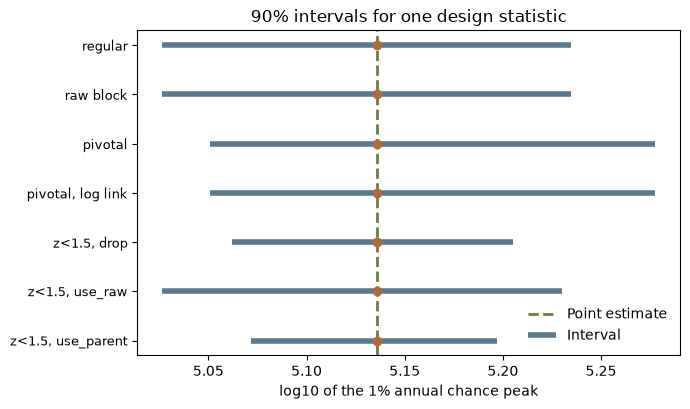

In [14]:
rows = [("regular", regular["lower"][2], regular["upper"][2]),
        ("raw block", piv["raw_lower"][2], piv["raw_upper"][2]),
        ("pivotal", piv["lower"][2], piv["upper"][2]),
        ("pivotal, log link", linked["lower"][2], linked["upper"][2])]
rows += [(f"z<1.5, {row['policy']}", row["lower"], row["upper"]) for row in policies]

fig, ax = plt.subplots(figsize=(7, 4.2))
y = np.arange(len(rows))[::-1]
ax.axvline(piv["estimate"][2], color="#6b7f3f", linestyle="--", linewidth=2,
           label="Point estimate")
ax.hlines(y, [r[1] for r in rows], [r[2] for r in rows], color="#5b7a8c", linewidth=4,
          label="Interval")
ax.plot([piv["estimate"][2]] * len(rows), y, "o", color="#b06a3b")
ax.set_yticks(y)
ax.set_yticklabels([r[0] for r in rows], fontsize=9)
ax.set_xlabel("log10 of the 1% annual chance peak")
ax.set_title("90% intervals for one design statistic")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()

## What reproduces across languages, and what does not

Most pages on this site can promise that a seeded run gives bit-identical numbers in R and Python,
because every operation on them happens inside the shared C++ core and the two packages call the
same compiled code. The callback path is where that promise needs a condition attached, and it is
better stated plainly than buried. It applies here, to example 13's custom objective, to example
14's custom posterior and to example 15's custom bootstrap alike.

The resampled INDICES still come from the core generator, so a given seed selects the identical
observations in the identical order in both languages, replicate for replicate. That half is
unconditional. The other half is not: `fit_with_covariance` and `statistic` are your own Python or R
code, and the two languages do not guarantee identical rounding for the same formula. A run
reproduces across languages if and only if your functions return bit-identical values.

The functions on this page do, and by construction rather than by luck. They add, subtract, multiply
and divide, and they take one square root. Arithmetic is IEEE-deterministic, and `sqrt` is the one
library function IEEE 754 requires to be correctly rounded, so both languages must return the same
bits for it. That is why the model here is a location-scale Normal in $\log_{10}$ space instead of
something fitted numerically: it keeps `log` and `exp` out of the callback, where they would put the
last bit at the mercy of two different math libraries. Every number this page prints is identical in
the R twin.

The package's own cross-language fixture pins the same construct.
`fixtures/callback/callback_cross_language.json` runs this exact model, on eight observations at
seed 12345, and asserts the pivotal and raw endpoints at ZERO tolerance, meaning bit equality rather
than a tolerance, across all four runners: the C++ fixture harness, R, Python, and the dotnet oracle
emitter driving the real C# `Bootstrap` class. The reproduction check below is that construct.

## Key takeaways

1. `run_type="pivotal"` reflects each replicate through the parent fit, standardized by the
   replicate's own covariance and reinflated by the parent's.
2. It fits through `fit_with_covariance(data)`, returning `parameters` and `covariance`. Passing
   `fit` as well is an error, not a preference.
3. Every pivotal run reports two interval blocks. The raw one is what a regular run would have said;
   the difference between them is the transform's contribution.
4. Read `pivotal_diagnostics` before reading the interval. `retained_pivotal_replicates` is the
   sample size the interval was actually computed from.
5. Standardize in link space when a parameter is constrained. Whether a given link changes the
   answer depends on the covariance, so check rather than assume.
6. Only `ci_method="Percentile"` exists after a pivotal run, and asking for another is refused
   before the first replicate rather than after all of them.

## Reproduction check

Two halves, carrying different weight.

The first pins this page's own numbers. Nothing upstream computes them, so they are a regression on
this file: they check that the page still produces what it produced when it was written. Because the
callbacks are arithmetic and `sqrt`, they are also the numbers the R twin prints.

The second is the construct the package's cross-language fixture pins, at zero tolerance, in all
four runners. Eight observations, the same Normal MLE with its analytic covariance, 200 replicates
at seed 12345. The literals were read from the real C# `Bootstrap` class by the dotnet oracle
emitter, and are compared here at 1e-15 relative.

In [15]:
def near(x, literal, tol=1e-15):
    return abs(x / literal - 1) < tol


x = [4.1, 5.2, 4.8, 5.5, 4.9, 5.1, 5.3, 4.7]
check = ch.bootstrap_custom(
    data=x, resample=resample_iid, statistic=lambda parameters: parameters,
    fit_with_covariance=fit_with_cov, run_type="pivotal",
    replicates=200, alpha=0.1, seed=12345,
)

# This page's own run: a within-Python regression, not an upstream literal (see above).
assert near(piv["estimate"][2], 5.1357565099517092)
assert near(piv["lower"][0], 4.6002343747987944)
assert near(piv["upper"][0], 4.7039019441786021)
assert near(piv["lower"][1], 0.16695444885212568)
assert near(piv["upper"][1], 0.27612953833178760)
assert near(piv["lower"][2], 5.0510777889516243)
assert near(piv["upper"][2], 5.2776613147818380)
assert near(piv["raw_lower"][2], 5.0264321098309954)
assert near(piv["raw_upper"][2], 5.2345946299122988)
assert np.array_equal(regular["lower"], piv["raw_lower"])
assert piv["pivotal_diagnostics"]["retained_pivotal_replicates"] == 400
assert piv["pivotal_diagnostics"]["invalid_pivotal_replicates"] == 0
assert near(linked["lower"][0], 4.6002794038957076)
assert near(linked["upper"][2], 5.2776620830082027)
assert [row["retained"] for row in policies] == [267, 400, 400]
assert [row["invalid"] for row in policies] == [133, 133, 133]

# The cross-language construct, read from the real C# Bootstrap class and pinned at zero
# tolerance in fixtures/callback/callback_cross_language.json.
assert near(check["lower"][0], 4.5677601616611)
assert near(check["upper"][0], 5.140545071728662)
assert near(check["lower"][1], 0.3182992562465546)
assert near(check["upper"][1], 0.9257315366348623)
assert near(check["standard_error"][0], 0.22495884650687556)
assert near(check["raw_lower"][0], 4.750000000000001)
assert near(check["raw_upper"][1], 0.5183806274882354)
assert check["pivotal_diagnostics"]["retained_pivotal_replicates"] == 200
assert len(check["estimate"]) == 2

print("All reproduction checks passed.")

All reproduction checks passed.
